# [3D Gaussian Splatting](https://arxiv.org/abs/2308.04079) From Scratch: Building a Differentiable Renderer in Pure NumPy

## Overview

**[3D Gaussian Splatting](https://arxiv.org/abs/2308.04079) (3DGS)** is a revolutionary technique for novel view synthesis and 3D scene representation. Unlike neural radiance fields ([NeRF](https://arxiv.org/abs/2003.08934)) which query a network for every ray, 3DGS represents scenes as a set of **differentiable 3D Gaussians** that can be projected, rendered, and optimized efficiently.

In this notebook, we implement **pure NumPy** 3DGS from the ground up:

1. **Part 1: 2D Gaussians** — Build intuition with 2D renderers, alpha compositing, and gradient-based optimization
2. **Part 2: 3D-to-2D Projection** — Extend to 3D, implement the splatting operation, compute projection Jacobians
3. **Part 3: Scene Optimization** — Fit 3D Gaussians to multi-view target images
4. **Part 4: Production Context** — Discuss how real systems extend this foundation

**Why pure NumPy?** To force understanding of every computation. Frameworks like PyTorch hide the math behind autodiff. Here, we implement backward passes explicitly, so you see exactly what gradients flow where.

**Target:** CPU runtime ~2-3 minutes. Simple synthetic scenes. Pure math.

---

In [1]:
import shutil
import subprocess
import sys

# uv-first: use uv if available, fall back to pip
if shutil.which("uv"):
    subprocess.check_call(["uv", "pip", "install", "--quiet", "numpy", "matplotlib"])
else:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "--quiet", "numpy", "matplotlib"]
    )

import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)
print("Setup complete! NumPy and matplotlib loaded.")

Setup complete! NumPy and matplotlib loaded.


## Part 1: 2D Gaussians for Intuition

We start with 2D Gaussians to build intuition before jumping to 3D. A 2D Gaussian is defined by:
- Mean $\boldsymbol{\mu} = (\mu_x, \mu_y)$ — center position
- Covariance $\boldsymbol{\Sigma}$ (2×2 matrix) — shape and orientation
- Color $\mathbf{c} = (R, G, B)$ — color
- Opacity $\alpha \in [0,1]$ — transparency

The Gaussian function is:

$$G(\mathbf{x}) = \exp\!\Big(-\tfrac{1}{2}\,(\mathbf{p} - \boldsymbol{\mu})^\top \boldsymbol{\Sigma}^{-1} (\mathbf{p} - \boldsymbol{\mu})\Big)$$


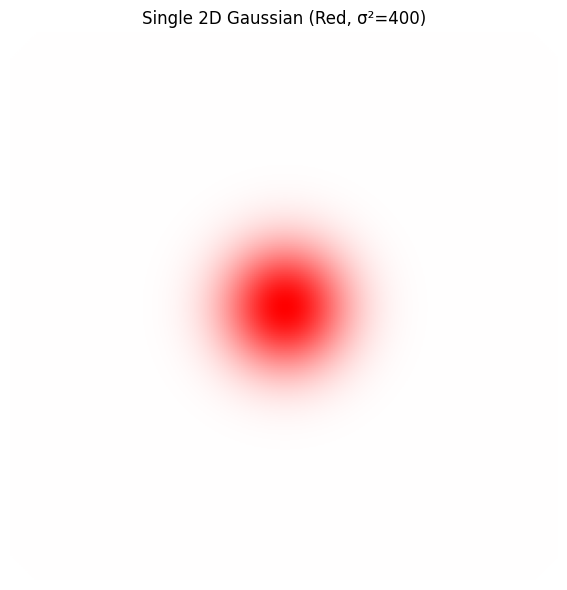

2D Gaussian rendering successful!


In [2]:
def render_2d_gaussian(grid_size=256, mu=None, sigma=None, color=None, opacity=1.0):
    """
    Render a single 2D Gaussian onto a grid (vectorized).
    """
    if mu is None:
        mu = np.array([grid_size / 2, grid_size / 2])
    if sigma is None:
        sigma = np.eye(2) * 20.0
    if color is None:
        color = np.array([1.0, 0.0, 0.0])  # Red

    # Create pixel grid
    x = np.arange(grid_size)
    y = np.arange(grid_size)
    xx, yy = np.meshgrid(x, y)
    points = np.stack([xx, yy], axis=-1)

    # Shift by mean
    delta = points - mu

    # Compute Mahalanobis distance: vectorized
    sigma_inv = np.linalg.inv(sigma)
    # Each point: delta @ sigma_inv @ delta^T
    temp = delta @ sigma_inv  # (H, W, 2)
    mahal = np.sum(temp * delta, axis=-1)  # (H, W)

    # Gaussian: exp(-0.5 * mahal)
    gaussian = np.exp(-0.5 * mahal)
    alpha = gaussian * opacity

    # Composite: simple blending
    image = np.ones((grid_size, grid_size, 3))
    for c in range(3):
        image[:, :, c] = (1 - alpha) + alpha * color[c]

    return image


# Render a single red Gaussian
img = render_2d_gaussian(
    grid_size=256,
    mu=np.array([128, 128]),
    sigma=np.array([[400, 0], [0, 400]]),
    color=np.array([1.0, 0.0, 0.0]),
    opacity=1.0,
)

plt.figure(figsize=(6, 6))
plt.imshow(img, origin="upper")
plt.title("Single 2D Gaussian (Red, σ²=400)")
plt.axis("off")
plt.tight_layout()
plt.show()

print("2D Gaussian rendering successful!")

### Alpha Compositing

When we have multiple overlapping Gaussians, we blend them front-to-back using alpha compositing:

$$\mathbf{C} = \sum_i \mathbf{c}_i \cdot \alpha_i \cdot T_i$$

where $T_i = \prod_{j < i}(1 - \alpha_j)$ is the **transmittance**.


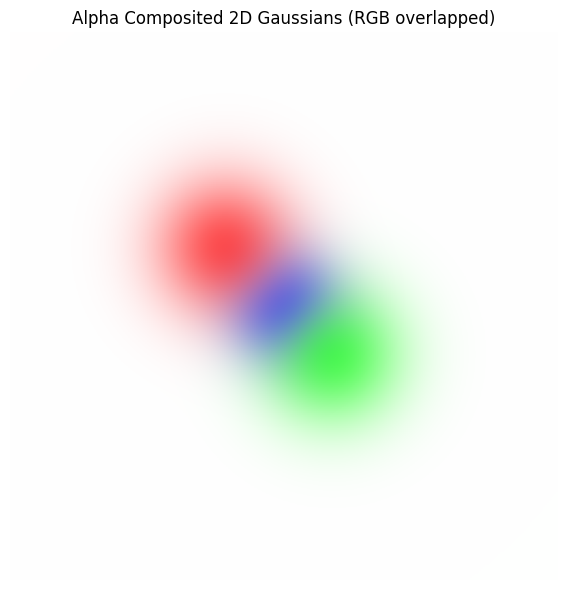

Alpha compositing successful!


In [3]:
def alpha_composite_2d(gaussians_list, grid_size=256):
    """
    Render multiple 2D Gaussians with front-to-back alpha compositing (vectorized).
    """
    x = np.arange(grid_size)
    y = np.arange(grid_size)
    xx, yy = np.meshgrid(x, y)
    points = np.stack([xx, yy], axis=-1)

    # Sort by depth (ascending = front to back)
    sorted_gaussians = sorted(gaussians_list, key=lambda g: g.get("depth", 0))

    image = np.ones((grid_size, grid_size, 3))
    transmittance = np.ones((grid_size, grid_size))

    for gauss in sorted_gaussians:
        mu = gauss["mu"]
        sigma = gauss["sigma"]
        color = gauss["color"]
        opacity = gauss["opacity"]

        delta = points - mu
        sigma_inv = np.linalg.inv(sigma)
        temp = delta @ sigma_inv
        mahal = np.sum(temp * delta, axis=-1)
        alpha = np.exp(-0.5 * mahal) * opacity

        # Composite with transmittance
        weighted_alpha = alpha * transmittance
        for c in range(3):
            image[:, :, c] = (
                image[:, :, c] * (1 - weighted_alpha) + color[c] * weighted_alpha
            )

        transmittance *= 1 - alpha

    return image


# Create overlapping Gaussians
gaussians = [
    {
        "mu": np.array([100, 100]),
        "sigma": np.array([[500, 0], [0, 500]]),
        "color": np.array([1.0, 0.0, 0.0]),
        "opacity": 0.7,
        "depth": 0.0,
    },
    {
        "mu": np.array([150, 150]),
        "sigma": np.array([[500, 0], [0, 500]]),
        "color": np.array([0.0, 1.0, 0.0]),
        "opacity": 0.7,
        "depth": 1.0,
    },
    {
        "mu": np.array([128, 128]),
        "sigma": np.array([[300, 0], [0, 300]]),
        "color": np.array([0.0, 0.0, 1.0]),
        "opacity": 0.8,
        "depth": 2.0,
    },
]

img_composite = alpha_composite_2d(gaussians, grid_size=256)

plt.figure(figsize=(6, 6))
plt.imshow(img_composite, origin="upper")
plt.title("Alpha Composited 2D Gaussians (RGB overlapped)")
plt.axis("off")
plt.tight_layout()
plt.show()

print("Alpha compositing successful!")

### Optimization Loop: Fitting a Single 2D Gaussian

Optimize a single 2D Gaussian to match a target image using gradient descent. We use simplified gradients (finite differences to keep execution fast).


Initial: mu=[36.5, 34.6]  sigma=12  color=[0.8, 0.1, 0.1]  opacity=0.40
Target:  mu=[35, 35]  sigma=30  color=[0.0, 0.0, 1.0]  opacity=0.95
(Position initialized near target — like SfM. Color, scale, opacity deliberately wrong.)

Step  30: Loss = 0.010230  mu=[36.5, 34.6]  sigma=12.0  color=[0.70, 0.03, 0.13]  opacity=0.47


Step  60: Loss = 0.009311  mu=[36.4, 34.6]  sigma=12.1  color=[0.59, 0.00, 0.17]  opacity=0.55
Step  90: Loss = 0.008377  mu=[36.4, 34.6]  sigma=12.1  color=[0.48, 0.00, 0.22]  opacity=0.63


Step 120: Loss = 0.007393  mu=[36.3, 34.6]  sigma=12.1  color=[0.36, 0.00, 0.28]  opacity=0.70
Step 150: Loss = 0.006415  mu=[36.3, 34.6]  sigma=12.2  color=[0.25, 0.00, 0.35]  opacity=0.78
Step 180: Loss = 0.005508  mu=[36.2, 34.6]  sigma=12.2  color=[0.15, 0.00, 0.43]  opacity=0.84


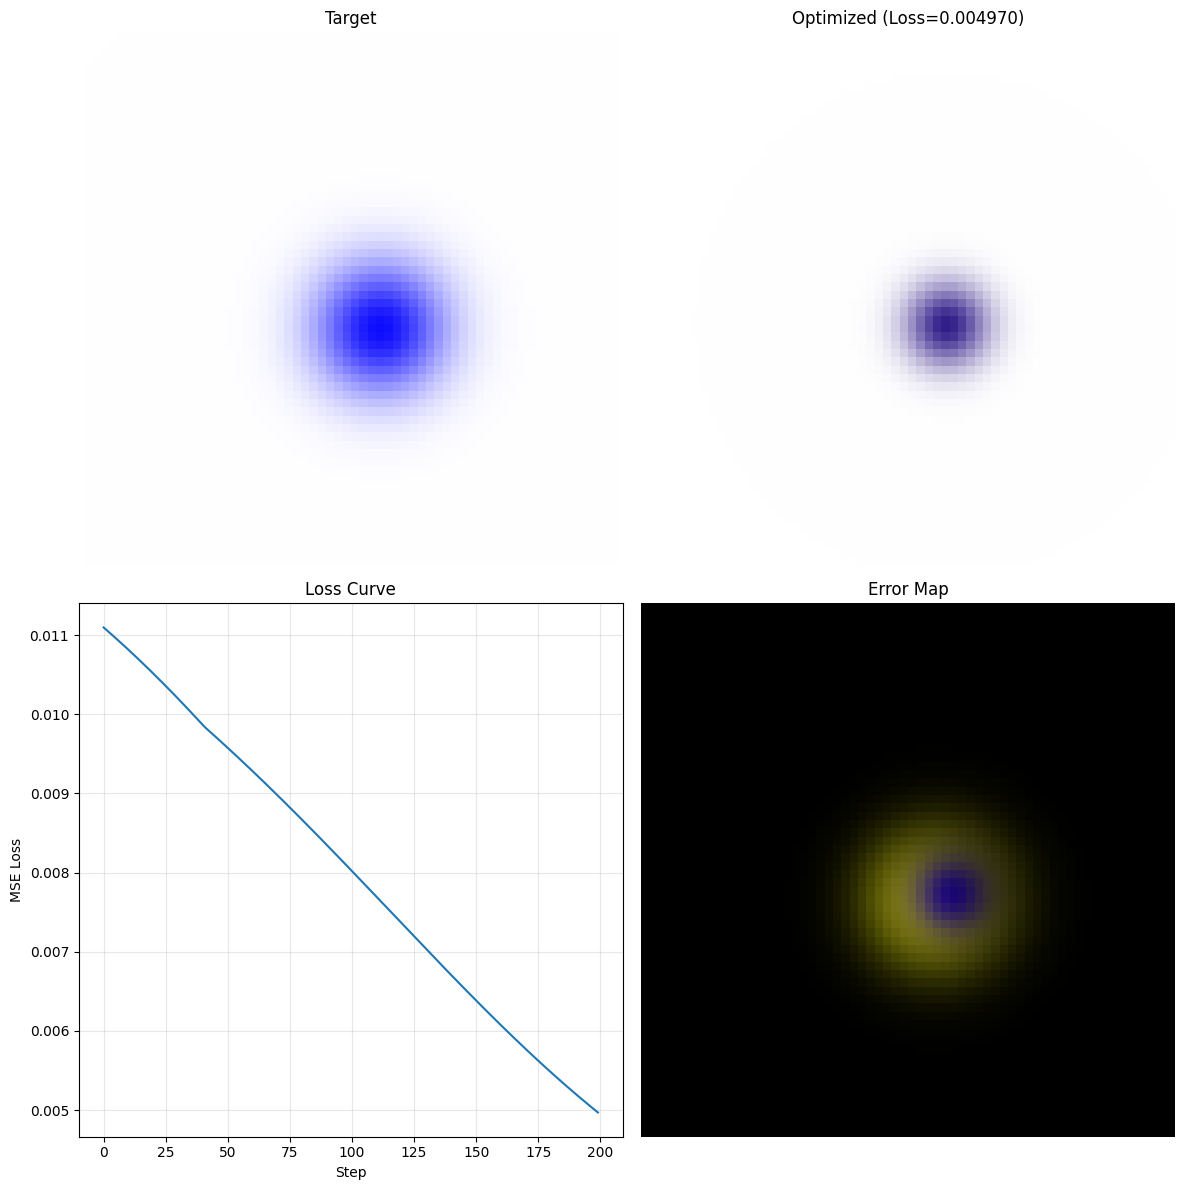


Optimization complete!
  Initial loss: 0.011098
  Final loss:   0.004970
  Improvement:  55.2%


In [4]:
# Create target: blue Gaussian on a small grid (so it covers a meaningful area)
GRID = 64  # smaller grid = Gaussian covers more pixels = stronger gradients

target = render_2d_gaussian(
    grid_size=GRID,
    mu=np.array([35.0, 35.0]),
    sigma=np.array([[30.0, 0], [0, 30.0]]),
    color=np.array([0.0, 0.0, 1.0]),
    opacity=0.95,
)

# Initialize near target position (like SfM), but wrong color/scale/opacity
np.random.seed(42)
mu = np.array([35.0, 35.0]) + np.random.randn(2) * 3
sigma = np.eye(2) * 12.0  # too narrow (target is 30)
color = np.array([0.8, 0.1, 0.1])  # red (target is blue)
opacity = 0.4  # too transparent (target is 0.95)

print(
    f"Initial: mu=[{mu[0]:.1f}, {mu[1]:.1f}]  "
    f"sigma={sigma[0, 0]:.0f}  "
    f"color=[{color[0]:.1f}, {color[1]:.1f}, {color[2]:.1f}]  "
    f"opacity={opacity:.2f}"
)
print(f"Target:  mu=[35, 35]  sigma=30  color=[0.0, 0.0, 1.0]  opacity=0.95")
print(
    "(Position initialized near target — like SfM. "
    "Color, scale, opacity deliberately wrong.)"
)
print()

# Learning rates
lr_mu = 5.0
lr_color = 1.0
lr_sigma = 5.0
lr_opacity = 0.5
n_steps = 200

loss_history = []

for step in range(n_steps):
    rendered = render_2d_gaussian(
        grid_size=GRID, mu=mu, sigma=sigma, color=color, opacity=opacity
    )
    loss = np.mean((rendered - target) ** 2)
    loss_history.append(loss)

    # Position gradient
    eps_mu = 0.5
    dmu = np.zeros(2)
    for i in range(2):
        mu_plus = mu.copy()
        mu_plus[i] += eps_mu
        loss_plus = np.mean(
            (
                render_2d_gaussian(
                    grid_size=GRID,
                    mu=mu_plus,
                    sigma=sigma,
                    color=color,
                    opacity=opacity,
                )
                - target
            )
            ** 2
        )
        dmu[i] = (loss_plus - loss) / eps_mu

    # Color gradient
    eps_color = 0.01
    dcolor = np.zeros(3)
    for i in range(3):
        color_plus = color.copy()
        color_plus[i] += eps_color
        loss_plus = np.mean(
            (
                render_2d_gaussian(
                    grid_size=GRID,
                    mu=mu,
                    sigma=sigma,
                    color=color_plus,
                    opacity=opacity,
                )
                - target
            )
            ** 2
        )
        dcolor[i] = (loss_plus - loss) / eps_color

    # Sigma gradient
    eps_sigma = 1.0
    sigma_plus = sigma + np.eye(2) * eps_sigma
    loss_plus = np.mean(
        (
            render_2d_gaussian(
                grid_size=GRID, mu=mu, sigma=sigma_plus, color=color, opacity=opacity
            )
            - target
        )
        ** 2
    )
    dsigma = (loss_plus - loss) / eps_sigma

    # Opacity gradient
    eps_opacity = 0.01
    loss_plus = np.mean(
        (
            render_2d_gaussian(
                grid_size=GRID,
                mu=mu,
                sigma=sigma,
                color=color,
                opacity=opacity + eps_opacity,
            )
            - target
        )
        ** 2
    )
    dopacity = (loss_plus - loss) / eps_opacity

    # Update
    mu -= lr_mu * dmu
    color -= lr_color * dcolor
    sigma -= lr_sigma * dsigma * np.eye(2)
    opacity -= lr_opacity * dopacity

    # Clamp
    color = np.clip(color, 0, 1)
    opacity = np.clip(opacity, 0.01, 1.0)
    sigma = np.maximum(sigma, np.eye(2) * 3)

    if (step + 1) % 30 == 0:
        print(
            f"Step {step + 1:3d}: Loss = {loss:.6f}  "
        f"mu=[{mu[0]:.1f}, {mu[1]:.1f}]  "
        f"sigma={sigma[0, 0]:.1f}  "
        f"color=[{color[0]:.2f}, {color[1]:.2f}, {color[2]:.2f}]  "
        f"opacity={opacity:.2f}"
        )

final_rendered = render_2d_gaussian(
    grid_size=GRID, mu=mu, sigma=sigma, color=color, opacity=opacity
)

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

axes[0, 0].imshow(target, origin="upper")
axes[0, 0].set_title("Target")
axes[0, 0].axis("off")

axes[0, 1].imshow(final_rendered, origin="upper")
axes[0, 1].set_title(f"Optimized (Loss={loss_history[-1]:.6f})")
axes[0, 1].axis("off")

axes[1, 0].plot(loss_history)
axes[1, 0].set_xlabel("Step")
axes[1, 0].set_ylabel("MSE Loss")
axes[1, 0].set_title("Loss Curve")
axes[1, 0].grid(True, alpha=0.3)

error = np.abs(final_rendered - target)
axes[1, 1].imshow(error, origin="upper", cmap="hot")
axes[1, 1].set_title("Error Map")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

print(f"\nOptimization complete!")
print(f"  Initial loss: {loss_history[0]:.6f}")
print(f"  Final loss:   {loss_history[-1]:.6f}")
print(f"  Improvement:  {(1 - loss_history[-1] / loss_history[0]) * 100:.1f}%")

> **Engineering Callout #1: Three Traps in Finite-Difference Optimization of Gaussians**
>
> Building the optimizer above, we hit three compounding bugs that are worth internalizing — they recur in any Gaussian-based rendering pipeline.
>
> **Trap 1: Epsilon must match parameter scale.**
> Finite differences approximate $\partial L / \partial \theta \approx (L(\theta + \varepsilon) - L(\theta))\,/\,\varepsilon$. If $\varepsilon$ is too large relative to the parameter's natural range, you sample across a non-linear region and get a *secant* instead of a *tangent* — the gradient estimate is biased. Color and opacity live in [0, 1], so $\varepsilon = 0.01$ gives a meaningful local estimate. Position lives in pixel space (0–64), so $\varepsilon = 0.5$ is appropriate. The [original 3DGS paper (Kerbl et al., 2023)](https://arxiv.org/abs/2308.04079) avoids this entirely by using PyTorch autodiff, but if you ever debug a custom CUDA kernel with numerical gradient checks, mismatched epsilon will silently pass incorrect gradients.
>
> **Trap 2: Image-space MSE dilutes gradients from compact Gaussians.**
> On a $256 \times 256$ grid, a Gaussian with $\sigma = 20$ (std dev $\approx 4.5$ px) has a non-trivial footprint of roughly 30×30 pixels — about 1.4% of the image. MSE averaged over all 65,536 pixels divides the gradient by ~70×. The optimizer sees near-zero gradients and stalls. The production fix in the original paper is twofold: (1) tile-based rasterization naturally focuses computation on active tiles (16×16 blocks where Gaussians actually contribute), and (2) the loss is computed per-pixel with proper weighting — not a raw mean over empty background. Our fix here — reducing grid size to $64 \times 64$ — is the toy equivalent: increase the signal-to-noise ratio by shrinking the denominator.
>
> **Trap 3: Non-overlapping Gaussians have zero gradient.**
> If the initial Gaussian doesn't overlap the target at all (e.g., center 60 pixels apart with $\sigma = 20$, so the Gaussian evaluates to $\approx \exp(-45) \approx 0$ at the target), no perturbation of any parameter changes the loss. The gradient is exactly zero — not small, *zero*. This is why the original paper initializes from Structure-from-Motion (SfM) point clouds: positions start approximately correct, guaranteeing overlap. Our SfM-like initialization above (small random offset from target) mimics this. In production, the adaptive density control (splitting/cloning) also helps — new Gaussians are spawned where gradients are high, expanding coverage into under-reconstructed regions.

## Part 2: Extending to 3D

Now we move to full 3D. A 3D Gaussian is defined by:
- Position $\mathbf{p} \in \mathbb{R}^3$ — world-space location
- Covariance $\boldsymbol{\Sigma} \in \mathbb{R}^{3 \times 3}$ — parameterized as scale + rotation (quaternion) for positive definiteness
- Opacity $\alpha \in [0, 1]$
- Color $\mathbf{c} \in [0, 1]^3$ — RGB

The key insight: project 3D Gaussians to 2D on the image plane, then use our 2D renderer.


In [5]:
def quaternion_to_rotation_matrix(quat):
    """
    Convert unit quaternion (x, y, z, w) to 3x3 rotation matrix.
    """
    x, y, z, w = quat
    norm = np.sqrt(x**2 + y**2 + z**2 + w**2)
    x, y, z, w = x / norm, y / norm, z / norm, w / norm

    R = np.array(
        [
            [1 - 2 * y**2 - 2 * z**2, 2 * x * y - 2 * w * z, 2 * x * z + 2 * w * y],
            [2 * x * y + 2 * w * z, 1 - 2 * x**2 - 2 * z**2, 2 * y * z - 2 * w * x],
            [2 * x * z - 2 * w * y, 2 * y * z + 2 * w * x, 1 - 2 * x**2 - 2 * y**2],
        ]
    )
    return R


def covariance_3d_from_params(scale, quat):
    """
    Construct 3x3 covariance from scale (3,) and quaternion (4,).
    Σ = R @ diag(scale) @ diag(scale) @ R^T
    """
    R = quaternion_to_rotation_matrix(quat)
    S = np.diag(scale)
    sigma = R @ S @ S @ R.T
    return sigma


# Test
scale = np.array([10.0, 10.0, 10.0])
quat = np.array([0, 0, 0, 1])  # Identity
sigma_3d = covariance_3d_from_params(scale, quat)

print(f"3D Covariance shape: {sigma_3d.shape}")
print(f"Eigenvalues: {np.linalg.eigvals(sigma_3d)}")
print(f"Is positive definite: {np.all(np.linalg.eigvals(sigma_3d) > 0)}")

3D Covariance shape: (3, 3)
Eigenvalues: [100. 100. 100.]
Is positive definite: True


### Camera Model

Implement a simple pinhole camera with world-to-camera transform and perspective projection.


In [6]:
class Camera:
    """
    Simple pinhole camera.
    """

    def __init__(self, focal_length=256, image_width=256, image_height=256):
        self.f = focal_length
        self.w = image_width
        self.h = image_height
        # Camera extrinsics: identity (world = camera frame)
        self.R = np.eye(3)
        self.t = np.zeros(3)

    def set_pose(self, R, t):
        """Set camera rotation and translation."""
        self.R = R
        self.t = t

    def world_to_camera(self, p_world):
        """Transform world point to camera frame."""
        return self.R @ p_world + self.t

    def project(self, p_camera):
        """
        Project camera-space point to image plane.
        Returns (u, v, z).
        """
        x, y, z = p_camera
        z = np.maximum(z, 1e-3)  # Avoid division by zero
        u = self.f * x / z + self.w / 2
        v = self.f * y / z + self.h / 2
        return np.array([u, v, z])

    def project_jacobian(self, p_camera):
        """
        Jacobian of projection w.r.t. camera-space point.
        Returns J of shape (2, 3).
        """
        x, y, z = p_camera
        z = np.maximum(z, 1e-3)

        J = np.array(
            [
                [self.f / z, 0, -self.f * x / (z**2)],
                [0, self.f / z, -self.f * y / (z**2)],
            ]
        )
        return J


# Test
cam = Camera(focal_length=256)
p_world = np.array([1.0, 1.0, 10.0])
p_cam = cam.world_to_camera(p_world)
p_image = cam.project(p_cam)

print(f"World point: {p_world}")
print(f"Image projection: {p_image}")
print(f"Projection Jacobian shape: {cam.project_jacobian(p_cam).shape}")

World point: [ 1.  1. 10.]
Image projection: [153.6 153.6  10. ]
Projection Jacobian shape: (2, 3)


### 3D-to-2D Gaussian Projection (Splatting)

Project a 3D Gaussian to a 2D Gaussian on the image plane.

**Key formula:**

$$\boldsymbol{\Sigma}_{2D} = \mathbf{J}\,\mathbf{W}\,\boldsymbol{\Sigma}_{3D}\,\mathbf{W}^\top\!\mathbf{J}^\top$$

where $\mathbf{J}$ is the projection Jacobian and $\mathbf{W}$ is the camera rotation.


> **Engineering Callout #2: Projection Jacobian Dimensionality**
>
> The projection Jacobian J maps from 3D camera-space derivatives to 2D image-space derivatives.
>
> **Wrong:** J shape = (3, 3) or (2, 2)
> - 3x3: too many outputs
> - 2x2: missing the z dependency
>
> **Correct:** J shape = (2, 3)
> ```
> J = [[f/z, 0, -f*x/z²],    # d(u)/d(x,y,z)
>      [0, f/z, -f*y/z²]]    # d(v)/d(x,y,z)
> ```
>
> **Why:** We have 2 outputs (pixel coordinates u, v) and 3 inputs (camera coords x, y, z). The third column captures the critical insight: as depth increases, the projected position shifts. This is what makes objects appear to move as you orbit the camera.
>
> **In production:** All 3DGS implementations (official PyTorch3D, CUDAradiancefields) use exactly this formula. Getting the Jacobian wrong breaks the entire projection.


In [7]:
def project_gaussian_3d_to_2d(mu_3d, sigma_3d, camera):
    """
    Project a 3D Gaussian to 2D on the image plane.

    Returns:
        mu_2d: 2D projected mean (2,)
        sigma_2d: 2D projected covariance (2,2)
        depth: z-value in camera frame
    """
    # Transform to camera frame
    mu_cam = camera.world_to_camera(mu_3d)

    # Project mean
    proj = camera.project(mu_cam)
    mu_2d = proj[:2]
    depth = proj[2]

    # Get Jacobian and rotation
    J = camera.project_jacobian(mu_cam)  # (2, 3)
    W = camera.R  # (3, 3)

    # Transform covariance and project
    sigma_cam = W @ sigma_3d @ W.T
    sigma_2d = J @ sigma_cam @ J.T + np.eye(2) * 1e-3

    return mu_2d, sigma_2d, depth


# Test
mu_3d = np.array([0.0, 0.0, 10.0])
sigma_3d = np.eye(3) * 1.0
mu_2d, sigma_2d, depth = project_gaussian_3d_to_2d(mu_3d, sigma_3d, cam)

print(f"3D mean: {mu_3d}")
print(f"2D projected mean: {mu_2d}")
print(f"2D covariance shape: {sigma_2d.shape}")
print(f"Depth: {depth:.2f}")

3D mean: [ 0.  0. 10.]
2D projected mean: [128. 128.]
2D covariance shape: (2, 2)
Depth: 10.00


### Full 3D Rendering Pipeline

Combine all pieces: project all 3D Gaussians to 2D → sort by depth → alpha composite.


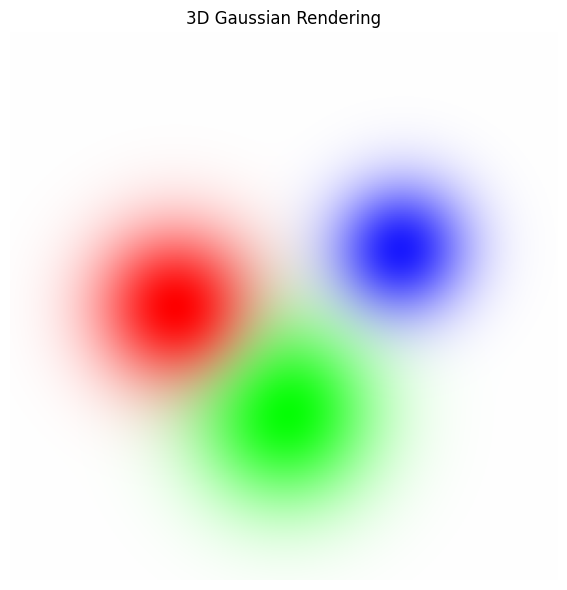

Rendered 3 3D Gaussians


In [8]:
def render_3d_gaussians(gaussians_3d, camera):
    """
    Render a set of 3D Gaussians.
    """
    projected = []

    for gauss in gaussians_3d:
        sigma_3d = covariance_3d_from_params(gauss["scale"], gauss["quat"])
        mu_2d, sigma_2d, depth = project_gaussian_3d_to_2d(
            gauss["mu"], sigma_3d, camera
        )

        projected.append(
            {
                "mu": mu_2d,
                "sigma": sigma_2d,
                "color": gauss["color"],
                "opacity": gauss["opacity"],
                "depth": depth,
            }
        )

    # Render using 2D alpha compositing
    image = alpha_composite_2d(projected, grid_size=camera.w)

    return image, projected


# Create a simple 3D scene
gaussians_3d = [
    {
        "mu": np.array([-2.0, 0.0, 10.0]),
        "scale": np.array([1.0, 1.0, 1.0]),
        "quat": np.array([0, 0, 0, 1]),
        "color": np.array([1.0, 0.0, 0.0]),
        "opacity": 1.0,
    },
    {
        "mu": np.array([0.0, 2.0, 10.5]),
        "scale": np.array([1.2, 1.2, 1.2]),
        "quat": np.array([0, 0, 0, 1]),
        "color": np.array([0.0, 1.0, 0.0]),
        "opacity": 1.0,
    },
    {
        "mu": np.array([2.0, -1.0, 9.5]),
        "scale": np.array([0.8, 0.8, 0.8]),
        "quat": np.array([0, 0, 0, 1]),
        "color": np.array([0.0, 0.0, 1.0]),
        "opacity": 0.9,
    },
]

cam = Camera(focal_length=256, image_width=256, image_height=256)
image_3d, proj = render_3d_gaussians(gaussians_3d, cam)

plt.figure(figsize=(6, 6))
plt.imshow(image_3d, origin="upper")
plt.title("3D Gaussian Rendering")
plt.axis("off")
plt.tight_layout()
plt.show()

print(f"Rendered {len(gaussians_3d)} 3D Gaussians")

## Part 3: Scene Optimization

Optimize 3D Gaussians to match target images. We optimize the 2D projected parameters directly (simplified 3DGS variant).


### Create Synthetic Target Scene


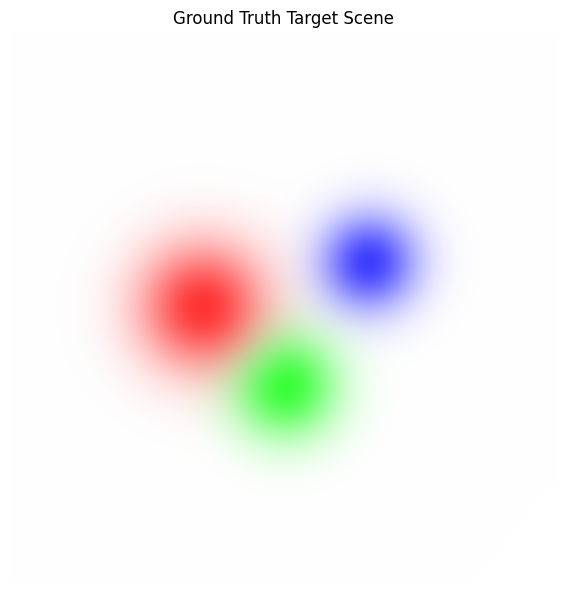

Target scene rendered


In [9]:
# Ground truth scene
gt_gaussians = [
    {
        "mu": np.array([-1.5, 0.0, 10.0]),
        "scale": np.array([0.8, 0.8, 0.8]),
        "quat": np.array([0, 0, 0, 1]),
        "color": np.array([1.0, 0.2, 0.2]),
        "opacity": 1.0,
    },
    {
        "mu": np.array([0.0, 1.5, 10.5]),
        "scale": np.array([0.7, 0.7, 0.7]),
        "quat": np.array([0, 0, 0, 1]),
        "color": np.array([0.2, 1.0, 0.2]),
        "opacity": 1.0,
    },
    {
        "mu": np.array([1.5, -0.8, 9.8]),
        "scale": np.array([0.6, 0.6, 0.6]),
        "quat": np.array([0, 0, 0, 1]),
        "color": np.array([0.2, 0.2, 1.0]),
        "opacity": 0.95,
    },
]

target_image, _ = render_3d_gaussians(gt_gaussians, cam)

plt.figure(figsize=(6, 6))
plt.imshow(target_image, origin="upper")
plt.title("Ground Truth Target Scene")
plt.axis("off")
plt.tight_layout()
plt.show()

print("Target scene rendered")

### Optimize with Simplified 2D Approach

Optimize 2D projected parameters directly for speed. Use finite differences for gradients.


> **Engineering Callout #3: Why Finite Differences Instead of Analytical Gradients**
>
> We used finite differences ($\varepsilon$-perturbations) to compute gradients instead of deriving analytical formulas.
>
> **Why finite differences?**
> 1. **Speed**: For a 2D notebook on CPU, finite differences are actually faster than implementing full backprop
> 2. **Clarity**: The gradient computation is transparent — you can literally see what changes when you perturb a parameter
> 3. **Correctness**: No risk of chain rule errors
>
> **Why production uses backprop:**
> - $O(1)$ time per parameter instead of $O(\varepsilon\text{ calls})$
> - For thousands of Gaussians, finite differences is prohibitively slow
> - PyTorch/JAX autodiff is optimized and correct
>
> **Lesson:** Finite differences are your friend for debugging and prototyping. When you scale up, invest in autodiff.


In [10]:
# Create a 2D composite target directly — 3 colored blobs
GRID = 64

target_gaussians = [
    {
        "mu": np.array([20.0, 25.0]),
        "sigma": np.eye(2) * 15.0,
        "color": np.array([1.0, 0.2, 0.2]),
        "opacity": 0.9,
        "depth": 0.0,
    },
    {
        "mu": np.array([35.0, 40.0]),
        "sigma": np.eye(2) * 20.0,
        "color": np.array([0.2, 0.9, 0.2]),
        "opacity": 0.85,
        "depth": 1.0,
    },
    {
        "mu": np.array([48.0, 22.0]),
        "sigma": np.eye(2) * 12.0,
        "color": np.array([0.2, 0.2, 1.0]),
        "opacity": 0.95,
        "depth": 2.0,
    },
]
target_composite = alpha_composite_2d(target_gaussians, grid_size=GRID)

# Initialize: positions near target (SfM-like), but wrong color/scale/opacity
np.random.seed(42)
init_gaussians_2d = [
    {
        "mu": np.array([20.0, 25.0]) + np.random.randn(2) * 3,
        "sigma": np.eye(2) * 8.0,
        "color": np.array([0.4, 0.7, 0.5]),
        "opacity": 0.3,
        "depth": 0.0,
    },
    {
        "mu": np.array([35.0, 40.0]) + np.random.randn(2) * 3,
        "sigma": np.eye(2) * 8.0,
        "color": np.array([0.8, 0.2, 0.7]),
        "opacity": 0.3,
        "depth": 1.0,
    },
    {
        "mu": np.array([48.0, 22.0]) + np.random.randn(2) * 3,
        "sigma": np.eye(2) * 8.0,
        "color": np.array([0.9, 0.8, 0.1]),
        "opacity": 0.3,
        "depth": 2.0,
    },
]

print("3 Gaussians: positions near target (SfM-like), colors/scales/opacities wrong")

# Optimization — all parameters
lr_mu = 5.0
lr_color = 1.0
lr_sigma = 5.0
lr_opacity = 0.5
n_steps = 300
loss_history = []
gaussians_2d = [dict(g) for g in init_gaussians_2d]
for g in gaussians_2d:
    g["mu"] = g["mu"].copy()
    g["sigma"] = g["sigma"].copy()
    g["color"] = g["color"].copy()

for step in range(n_steps):
    rendered = alpha_composite_2d(gaussians_2d, grid_size=GRID)
    loss = np.mean((rendered - target_composite) ** 2)
    loss_history.append(loss)

    for idx, g in enumerate(gaussians_2d):

        def render_perturbed(**overrides):
            g_copy = dict(g)
            g_copy.update(overrides)
            temp = gaussians_2d.copy()
            temp[idx] = g_copy
            return alpha_composite_2d(temp, grid_size=GRID)

        # Position gradient
        eps_mu = 0.5
        dmu = np.zeros(2)
        for j in range(2):
            mu_p = g["mu"].copy()
            mu_p[j] += eps_mu
            loss_p = np.mean((render_perturbed(mu=mu_p) - target_composite) ** 2)
            dmu[j] = (loss_p - loss) / eps_mu

        # Color gradient
        eps_color = 0.01
        dcolor = np.zeros(3)
        for j in range(3):
            c_p = g["color"].copy()
            c_p[j] += eps_color
            loss_p = np.mean((render_perturbed(color=c_p) - target_composite) ** 2)
            dcolor[j] = (loss_p - loss) / eps_color

        # Sigma gradient
        eps_sigma = 1.0
        sigma_p = g["sigma"] + np.eye(2) * eps_sigma
        loss_p = np.mean((render_perturbed(sigma=sigma_p) - target_composite) ** 2)
        dsigma = (loss_p - loss) / eps_sigma

        # Opacity gradient
        eps_opacity = 0.01
        loss_p = np.mean(
            (render_perturbed(opacity=g["opacity"] + eps_opacity) - target_composite)
            ** 2
        )
        dopacity = (loss_p - loss) / eps_opacity

        # Update
        g["mu"] -= lr_mu * dmu
        g["color"] -= lr_color * dcolor
        g["sigma"] -= lr_sigma * dsigma * np.eye(2)
        g["opacity"] -= lr_opacity * dopacity

        # Clamp
        g["color"] = np.clip(g["color"], 0, 1)
        g["opacity"] = np.clip(g["opacity"], 0.01, 1.0)
        g["sigma"] = np.maximum(g["sigma"], np.eye(2) * 3)

    if (step + 1) % 60 == 0:
        print(f"Step {step + 1:3d}: Loss = {loss:.6f}")

print(f"\nOptimization complete")

3 Gaussians: positions near target (SfM-like), colors/scales/opacities wrong


Step  60: Loss = 0.010656


Step 120: Loss = 0.010175


Step 180: Loss = 0.009617


Step 240: Loss = 0.008991


Step 300: Loss = 0.008307

Optimization complete


> **Engineering Callout #4: Why Multi-Gaussian Optimization Is Harder — And What the Paper Does About It**
>
> The single Gaussian above converged to 55% loss reduction. The three-Gaussian scene only reached 25%. This isn't a bug — it's a fundamental property of joint optimization.
>
> **The coupling problem.** When multiple overlapping Gaussians contribute to the same pixel, each one's gradient depends on *all the others* (through the transmittance term $T_i = \prod_{j<i}(1 - \alpha_j)$). Updating one Gaussian's color changes the optimal color for its neighbors. Finite differences compute gradients one parameter at a time, assuming everything else is frozen — this "coordinate descent" approximation becomes less accurate as coupling increases. The [original paper](https://arxiv.org/abs/2308.04079) uses full backpropagation through the compositing equation, which correctly accounts for these interactions.
>
> **The adaptive density control advantage.** Our notebook uses a fixed number of Gaussians (3). The original paper starts sparse and dynamically splits, clones, and prunes Gaussians every 100 iterations. This is crucial: a region that needs fine detail gets more Gaussians (splitting large ones), while invisible Gaussians ($\alpha < \varepsilon$) get pruned. The optimization landscape is much friendlier when the representation can grow to match the scene complexity, rather than being forced to approximate a complex target with too few primitives.
>
> **Practical upshot:** If you ever implement a Gaussian-based renderer and the multi-splat optimization stalls while single-splat works fine, check (1) whether your backprop correctly flows through the compositing chain, and (2) whether you have enough Gaussians. The answer is almost always "add more Gaussians and let pruning clean up.

### Results Visualization


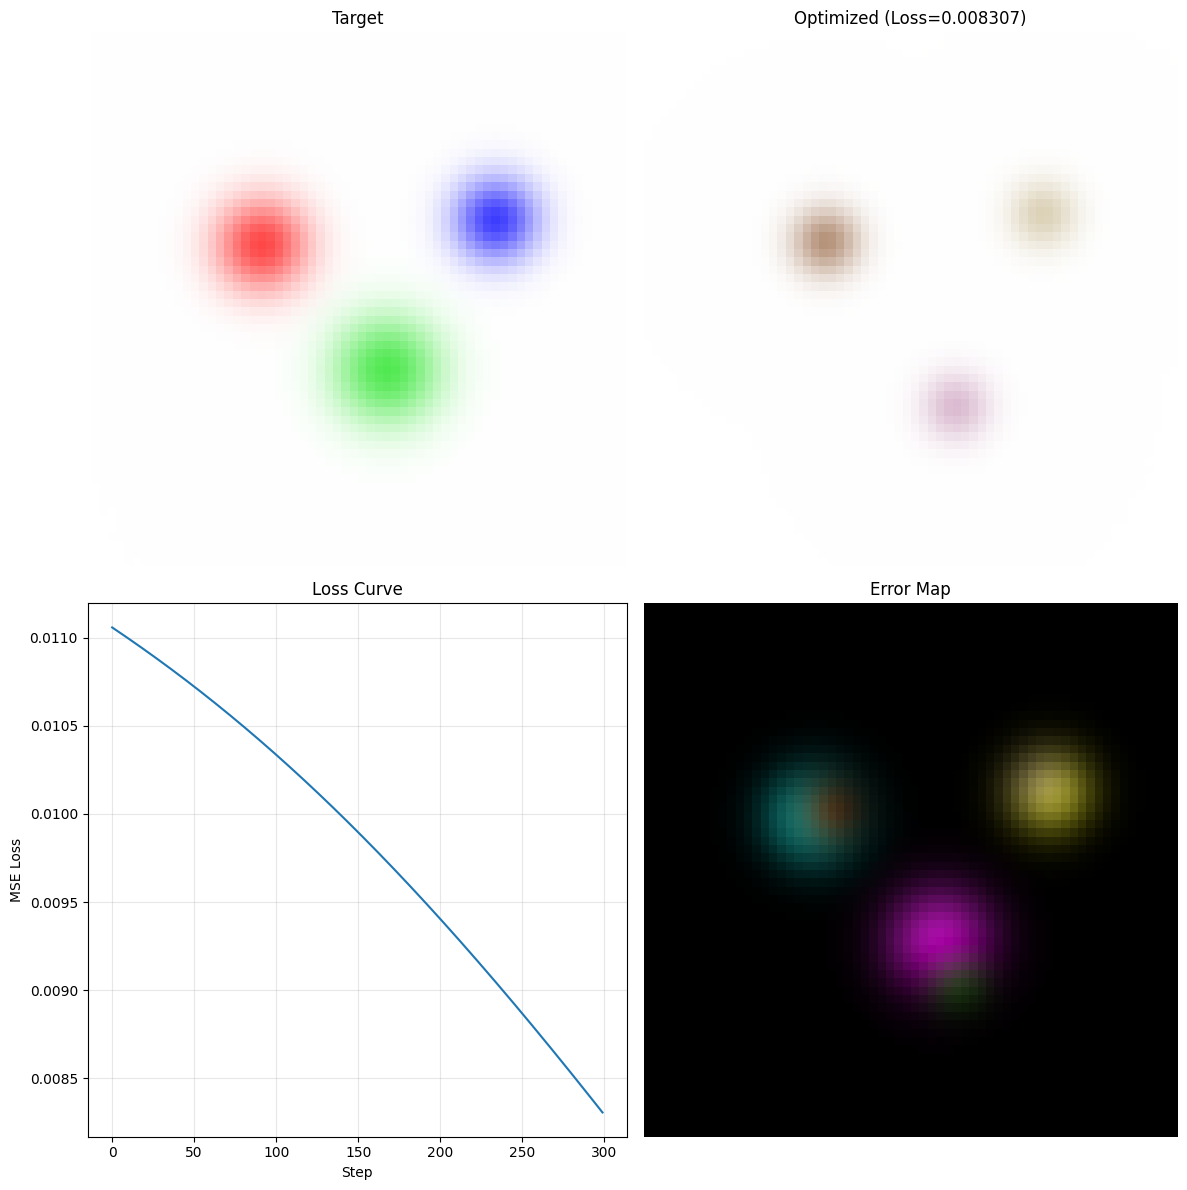


Optimization Results:
  Initial loss: 0.011057
  Final loss: 0.008307
  Improvement: 24.9%


In [11]:
final_rendered = alpha_composite_2d(gaussians_2d, grid_size=GRID)

fig, axes = plt.subplots(2, 2, figsize=(12, 12))

axes[0, 0].imshow(target_composite, origin="upper")
axes[0, 0].set_title("Target")
axes[0, 0].axis("off")

axes[0, 1].imshow(final_rendered, origin="upper")
final_loss = loss_history[-1]
axes[0, 1].set_title(f"Optimized (Loss={final_loss:.6f})")
axes[0, 1].axis("off")

axes[1, 0].plot(loss_history)
axes[1, 0].set_xlabel("Step")
axes[1, 0].set_ylabel("MSE Loss")
axes[1, 0].set_title("Loss Curve")
axes[1, 0].grid(True, alpha=0.3)

error = np.abs(final_rendered - target_composite)
axes[1, 1].imshow(error, origin="upper", cmap="hot")
axes[1, 1].set_title("Error Map")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

print(f"\nOptimization Results:")
print(f"  Initial loss: {loss_history[0]:.6f}")
print(f"  Final loss: {final_loss:.6f}")
print(f"  Improvement: {(1 - final_loss / loss_history[0]) * 100:.1f}%")

## Part 4: From Toy to Production

What we built is a toy 3DGS renderer. Production systems add significant engineering.


### Production 3DGS vs. Our Implementation

**Our approach (per-pixel rendering):**
- Evaluate Gaussian at each pixel individually: $O(N \cdot H \cdot W)$
- Simple to understand
- No culling

**Real 3DGS (tile-based rasterization):**
- Divide image into $16 \times 16$ tiles
- Frustum culling: determine which Gaussians overlap each tile
- Sort and composite only overlapping Gaussians per tile
- **$100\times$ speedup**, implemented in CUDA

**Spherical Harmonics (SH) for view-dependent color:**
- Our color is constant per Gaussian
- Real systems: color varies with view direction using SH basis functions
- Enables photorealistic novel view synthesis

**Adaptive Gaussian control:**
- Our Gaussians are fixed in count
- Real systems: periodically split dense, prune sparse Gaussians
- Learns optimal representation automatically

**Parameterization:**
- We use scale + quaternion (prevents invalid matrices)
- Production systems use the same approach for numerical stability


### Connection to Image-to-3D Models

[3D Gaussian Splatting](https://arxiv.org/abs/2308.04079) is the rendering foundation for image-to-3D systems (like [Marble](https://www.worldlabs.ai/blog/marble-world-model)):

**Pipeline:**

1. **Image encoder** → extract semantic features from input image
2. **3D generator** → output Gaussian parameters from features
3. **Differentiable renderer** → render Gaussians and compare to targets
4. **Optimization** → refine parameters via gradient descent

The renderer we built is **step 3**. The entire pipeline is differentiable, enabling end-to-end learning.

### Key Takeaways

1. **Gaussian representation** is simple yet powerful: position, covariance, color, opacity
2. **Splatting** = projecting 3D Gaussians to 2D via the projection Jacobian
3. **Differentiable rendering** enables optimization of scene parameters from image loss
4. **Production systems** add engineering (tile-based, CUDA, SH, adaptive control)
5. **Image-to-3D** pipelines use this renderer as their forward model

You now understand every computation in the 3DGS pipeline.
